In [ ]:
import matplotlib.pyplot as plt

from wattson.models.power_supply import Battery
from wattson.models.database import Database

In [3]:
battery = Battery()
database = Database()

In [4]:
for _ in dir(battery):
    if _.startswith("_"):
        continue
    print(_, battery.__getattribute__(_), sep=": ")

BATTERY_NAME: BAT0
POWER_INFORMATION_LOCATION: /sys/class/power_supply
energy_full_design: 45000000
manufacturer: SMP
model_name: L14M4P72
serial_number:  1280
technology: Li-poly
type: Battery
voltage_min_design: 7400000


In [5]:
df = database.get_data()

/home/tortugellini/git/wattson/src/wattson/models/database.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {self.database}", con=self.connection)


In [6]:
df.set_index("time_now_seconds", inplace=True)

In [7]:
df

,time_last_modified,voltage,energy,power,capacity
time_now_seconds,,,,,
1747594598,1747285235,7999000,32730000.0,0.0,100
1747594598,1747285235,7999000,32730000.0,0.0,100
1747594599,1747285235,7999000,32730000.0,0.0,100
1747594600,1747285235,7999000,32730000.0,0.0,100
1747594600,1747285235,7999000,32730000.0,0.0,100
...,...,...,...,...,...
1748101437,1747285235,8055000,32490000.0,0.0,100
1748101438,1747285235,8055000,32490000.0,0.0,100
1748101438,1747285235,8055000,32490000.0,0.0,100


voltage = df.voltage.to_numpy()
power = df.power.to_numpy()
capacity = df.capacity.to_numpy()

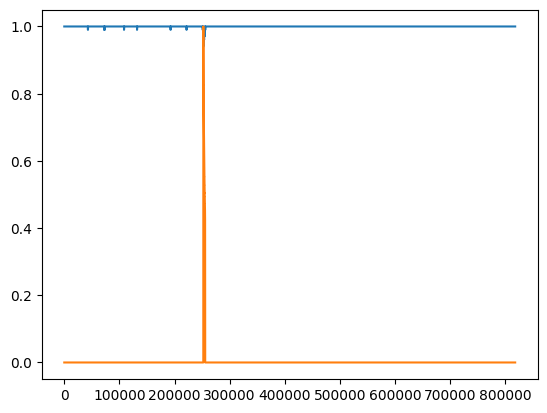

In [19]:
plt.plot(capacity / max(capacity))
plt.plot(power / max(power))